# ILUSTR 2 — Transmisja błędów: jak błąd danych wejściowych przechodzi przez obliczenia

Pokrywa: slajdy 11–30 oraz 51–62 prezentacji ZW_1 („Transmisja błędów", „Błąd zaokrągleń",
„Pełna analiza błędów — rachunek epsilonów") i odpowiadające sekcje konspektu.

Idea: dane wejściowe $x$ obarczone błędem $\Delta x$ wchodzą do funkcji $y = f(x)$.
Błąd wyniku zależy nie tylko od wielkości błędu wejściowego, ale też od **tego, jak silnie
funkcja reaguje** na zmianę argumentu — a o tym decyduje pochodna:

$$\Delta y \approx \Delta x\left|\frac{dy}{dx}\right|, \qquad
\delta y = \underbrace{\left|\frac{x}{y}\frac{dy}{dx}\right|}_{T}\cdot\delta x$$

Bezwymiarowy współczynnik $T$ to **współczynnik transmisji błędu**: mówi, ile razy operacja
$y=f(x)$ powiększy (albo zmniejszy) względny błąd swoich danych. Dla funkcji wielu zmiennych
błędywkłady sumują się: $\delta y = \sum_i T_i\, \delta x_i$.

**Uwaga z wykładu (slajd 20): to wzór przybliżony — pochodzi z obcięcia rozwinięcia Taylora
po pierwszym członie. Jest dobry dla małych błędów.** W tym notatniku sprawdzimy *numerycznie*,
dokąd sięga jego trafność — i zobaczymy na żywo, jak łamie się przy błędach dużych.

In [2]:
# Demo 1: współczynnik transmisji T dla typowych operacji.
# Wzór: T = |x/y * dy/dx|. Policzymy go analitycznie (z definicji) dla kilku funkcji.
import numpy as np
import matplotlib.pyplot as plt

x = 1.7   # punkt, w którym porównujemy operacje
operacje = [
    ("x^2     (potega)",      x**2,   2*x),
    ("x^3     (potega)",      x**3,   3*x**2),
    ("exp(x)  (eksponens)",   np.exp(x),  np.exp(x)),
    ("ln(x)   (logarytm)",    np.log(x),  1/x),
    ("sqrt(x) (pierwiastek)", np.sqrt(x), 0.5/np.sqrt(x)),
]
print(f"Punkt x = {x}:")
for nazwa, y, dydx in operacje:
    T = abs(x * dydx / y)
    print(f"  {nazwa:24s} T = {T:.3f}")

# Wnioski do zapamiętania:
#  - potegowanie: T = stopien potegi (x^2 podwaja blad wzgledny, x^3 potraja)
#  - pierwiastek TANMI: T = 1/2 — sqrt "wygladza" blad wzgledny o polowe
#  - exp: T = x — wzmacnia blad tyle razy, ile wynosi argument
#  - ln:  T = 1/ln(x) — dla x>1 TUMI blad (bo ln rosnie wolniej niz x)

Punkt x = 1.7:
  x^2     (potega)         T = 2.000
  x^3     (potega)         T = 3.000
  exp(x)  (eksponens)      T = 1.700
  ln(x)   (logarytm)       T = 1.885
  sqrt(x) (pierwiastek)    T = 0.500


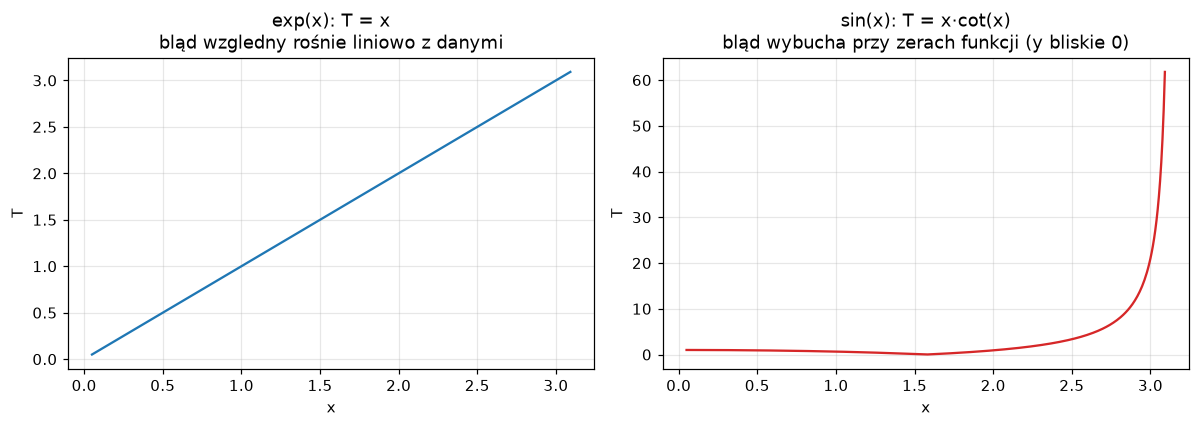

In [3]:
# Jak T zalezy od punktu: exp wzmacnia rosnaco, sin ma "strefy eksplozji" przy zerach.
xs = np.linspace(0.05, np.pi-0.05, 400)
T_exp = xs                      # T = x dla exp(x)
T_sin = np.abs(xs * np.cos(xs) / np.sin(xs))   # T = x*cot(x) dla sin(x)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(xs, T_exp, 'tab:blue')
ax1.set_xlabel('x'); ax1.set_ylabel('T'); ax1.grid(alpha=.3)
ax1.set_title('exp(x): T = x\nbląd wzgledny rośnie liniowo z danymi')

ax2.plot(xs, T_sin, 'tab:red')
ax2.set_xlabel('x'); ax2.set_ylabel('T'); ax2.grid(alpha=.3)
ax2.set_title('sin(x): T = x·cot(x)\nbląd wybucha przy zerach funkcji (y bliskie 0)')
plt.tight_layout(); plt.show()

# Przy x=3.0 (blisko pierwiastka pi) T spada do ok. -21, |T|~21: blad wzgledny
# argumentu zostanie zwielokrotniony ~21 razy, bo funkcja prawie sie zeruje
# (mianownik y w definicji T).

## Przykład 1 (slajdy 13–15): obwód rury z pomiaru suwmiarką

Średnicę rury zmierzono suwmiarką z błędem względnym $\delta D \approx 0.4\%$, a do wzoru
na obwód $O = \pi D$ podstawiono przybliżenie liczby $\pi$ obarczone $\delta\pi \approx 0.3\%$.

Rozwiązanie analityczne z wykładu: oba składniki wchodzą z współczynnikiem $T=1$
(wzór iloczynowy to suma błędów względnych), więc $\delta O = \delta D + \delta\pi \approx 0.7\%$.

Poniżej **symulacja Monte Carlo**: losujemy 200 tys. par błędów z dopuszczalnych zakresów
i patrzymy, jaki najgorszy błąd obwodu faktycznie się zdarza — i czy mieści się w oszacowaniu.

Oszacowanie z wykladu (liniowe):  dO <= 0.4% + 0.3% = 0.7%
Najgorszy przypadek z MC:          0.6989%
Sredni blad:                       0.2377%

Wzór liniowy TRZYMA sie z zapasem, bo błędy wejściowe są małe (rzędu promila).


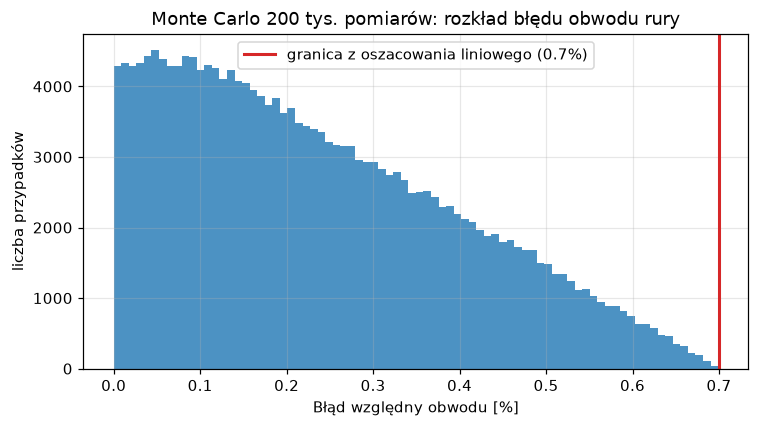

In [5]:
# Demo 2: weryfikacja Monte Carlo przykładu rury (błędy MAŁE -> wzór liniowy trzyma).
rng = np.random.default_rng(42)
N = 200_000

D_dokladne = 2.0                                   # m — prawdziwa srednica (nieznana w praktyce)
dD = rng.uniform(-0.004, 0.004, N)                 # blad suwmiarki: do +-0.4%
dpi = rng.uniform(-0.003, 0.003, N)                # blad przyblizenia pi: do +-0.3%

O = np.pi * (1 + dpi) * D_dokladne * (1 + dD)      # obwody "wyliczone z zepsutymi danymi"
O_dokladny = np.pi * D_dokladne
blad_wzgledny_O = np.abs(O - O_dokladny) / O_dokladny

print(f"Oszacowanie z wykladu (liniowe):  dO <= 0.4% + 0.3% = 0.7%")
print(f"Najgorszy przypadek z MC:          {blad_wzgledny_O.max()*100:.4f}%")
print(f"Sredni blad:                       {blad_wzgledny_O.mean()*100:.4f}%")
print()
print("Wzór liniowy TRZYMA sie z zapasem, bo błędy wejściowe są małe (rzędu promila).")

plt.figure(figsize=(7, 4))
plt.hist(blad_wzgledny_O*100, bins=80, color='tab:blue', alpha=.8)
plt.axvline(0.7, color='tab:red', lw=2, label='granica z oszacowania liniowego (0.7%)')
plt.xlabel('Błąd względny obwodu [%]'); plt.ylabel('liczba przypadków')
plt.title('Monte Carlo 200 tys. pomiarów: rozkład błędu obwodu rury')
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## Przykład 2 (slajdy 16–17): masa kostki z pomiaru linijką — tu wzór liniowy ZAWODZI

Krawędź kostki zmierzono linijką ($\delta a \approx 5\%$), gęstość wzięto z tablic
($\delta\rho \approx 8\%$). Masa: $m = \rho\, a^3$, więc
$\delta m = 1\cdot\delta\rho + 3\cdot\delta a \approx 8\% + 15\% = 23\%$.

To ten sam rachunek co przy rurze — ale błędy wejściowe są teraz **duże** (procenty, nie promille).
Zobacz, co się stanie z liniowym oszacowaniem:

Oszacowanie LINIOWE z wykladu:  dm <= 1*8% + 3*5% = 23%
Najgorszy przypadek z MC:        25.00%

Rozwinięcie DOKŁADNE (1+da)^3*(1+drho) dla da=5%, drho=8%: 25.02%

Różnica to człony wyższych rzędów, które wzór liniowy odrzucił:
  3*da^2        = 0.75 p.p.
  da^3          = 0.013 p.p.
  3*da*drho      = 1.20 p.p.
  (reszta)       = 0.06 p.p.

WNIOSEK: wzór liniowy to przybliżenie. Przy błędach promila — wyśmienite
(rura), przy błędach kilku procent — zaniża o punkty procentowe (kostka).


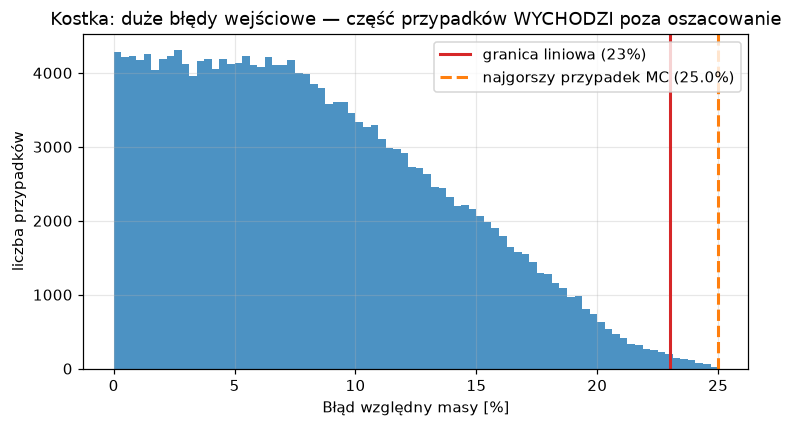

In [7]:
# Demo 3: ta sama procedura, duze błedy wejsciowe (5% i 8%) -> wzór liniowy ZA NISKO.
a_dokladne, rho_dokladne = 0.02, 2700             # m, kg/m^3
da  = rng.uniform(-0.05, 0.05, N)                  # blad linijki: do +-5%
drho = rng.uniform(-0.08, 0.08, N)                 # blad gestosci: do +-8%

m = rho_dokladne * (1 + drho) * (a_dokladne * (1 + da))**3
m_dokladna = rho_dokladne * a_dokladne**3
blad_m = np.abs(m - m_dokladna) / m_dokladna

print(f"Oszacowanie LINIOWE z wykladu:  dm <= 1*8% + 3*5% = 23%")
print(f"Najgorszy przypadek z MC:        {blad_m.max()*100:.2f}%")
print()

# Dokladny najgorszy przypadek (wszystkie błędy maksymalne, jednostronnie):
najgorszy = (1 + 0.05)**3 * (1 + 0.08) - 1
print(f"Rozwinięcie DOKŁADNE (1+da)^3*(1+drho) dla da=5%, drho=8%: {najgorszy*100:.2f}%")
print()
print("Różnica to człony wyższych rzędów, które wzór liniowy odrzucił:")
print(f"  3*da^2        = {3*0.05**2*100:.2f} p.p.")
print(f"  da^3          = {0.05**3*100:.3f} p.p.")
print(f"  3*da*drho      = {3*0.05*0.08*100:.2f} p.p.")
print(f"  (reszta)       = {(najgorszy-0.23-3*0.05**2-0.05**3-3*0.05*0.08)*100:.2f} p.p.")
print()
print("WNIOSEK: wzór liniowy to przybliżenie. Przy błędach promila — wyśmienite")
print("(rura), przy błędach kilku procent — zaniża o punkty procentowe (kostka).")

plt.figure(figsize=(7, 4))
plt.hist(blad_m*100, bins=80, color='tab:blue', alpha=.8)
plt.axvline(23, color='tab:red', lw=2, label='granica liniowa (23%)')
plt.axvline(blad_m.max()*100, color='tab:orange', lw=2, ls='--',
            label=f'najgorszy przypadek MC ({blad_m.max()*100:.1f}%)')
plt.xlabel('Błąd względny masy [%]'); plt.ylabel('liczba przypadków')
plt.title('Kostka: duże błędy wejściowe — część przypadków WYCHODZI poza oszacowanie')
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## Pełna analiza (slajdy 54–62): exp(x² + 1) krok po kroku na maszynie float32

Konspekt prowadzi rachunek epsilonów dla $y = \exp(x^2+1)$: każdy składnik obliczenia
(potęgowanie, dodanie 1, eksponens) transmituje błąd dalej *i dokłada własny błąd
zaokrąglenia* $\eta$. Wzór końcowy z wykładu:

$$\delta y = x^2\,(2\,\delta x + \eta_{\xi^2} + \eta_{\xi+1}) + \eta_{\xi+1} + \eta_{\exp}$$

Zauważ zależność od **samych danych wejściowych**: błąd wyniku rośnie jak $x^2$ nawet
przy stałym błędzie danych. Sprawdzimy to symulacją: policzymy $y$ w arytmetyce float32
(duże zaokrąglenia, ~7 cyfr znaczących) i porównamy z wartością dokładną.

In [9]:
# Demo 4: exp(x^2+1) w maszynie float32 vs oszacowanie z rachunku epsilonow.
# Model maszyny: kazda operacja elementarna (kwadrat, +1, exp) koaczy sie ZAOKRĄGLENIEM
# do float32, czyli doklada blad wzgledny rzędu eps32 (w najgorszym przypadku).
def f32(u):
    return np.float32(u)

eps32 = float(np.nextafter(np.float32(1), np.float32(2)) - np.float32(1))   # 1.19e-7
print(f"eps32 = {eps32:.3e}")

def maszyna_f32(x):
    """exp(x^2+1) wykonane KROK PO KROKU w arytmetyce float32 (jak procesor)."""
    k1 = f32(x * x)          # 1) potegowanie + zaokraglenie eta_kw
    k2 = f32(k1 + f32(1))    # 2) dodanie 1 + zaokraglenie eta_dod
    return np.exp(k2)        # 3) exp + zaokraglenie eta_exp

import math
print(f"{'x':>6} {'delta_x (reprez.)':>18} {'oszacowanie':>14} {'bląd rzecz.':>12}")
for xt in [0.5, 1.0, 2.0, 3.0, 4.0, 5.0]:
    x32 = f32(xt)                                 # wejscie juz obciazone bledem reprezentacji
    dx_in = abs(float(x32) - xt) / xt             # blad wzgledny reprezentacji danych
    bound = xt**2 * (2*dx_in + 2*eps32) + 2*eps32 # wzor z wykladu (eta = eps32)
    y_masz = float(maszyna_f32(x32))              # wynik maszyny float32
    y_dokl = math.exp(xt**2 + 1)                  # wynik idealny (float64 ma zapas)
    actual = abs(y_masz - y_dokl) / y_dokl
    print(f"{xt:6.1f} {dx_in:18.2e} {bound:14.2e} {actual:12.2e}")

print()
print("Blad wyniku rosnie jak x^2 — przy STALYM błędzie danych wejściowych (eps32).")
print("To wniosek slajdu 60: dokladnosc zalezy tez od POZIOMU danych, nie tylko od błędu.")

eps32 = 1.192e-07
     x  delta_x (reprez.)    oszacowanie  bląd rzecz.
   0.5           0.00e+00       2.98e-07     2.92e-08
   1.0           0.00e+00       4.77e-07     5.01e-08
   2.0           0.00e+00       1.19e-06     2.11e-08
   3.0           0.00e+00       2.38e-06     4.55e-08
   4.0           0.00e+00       4.05e-06     1.14e-07
   5.0           0.00e+00       6.20e-06     2.46e-08

Blad wyniku rosnie jak x^2 — przy STALYM błędzie danych wejściowych (eps32).
To wniosek slajdu 60: dokladnosc zalezy tez od POZIOMU danych, nie tylko od błędu.


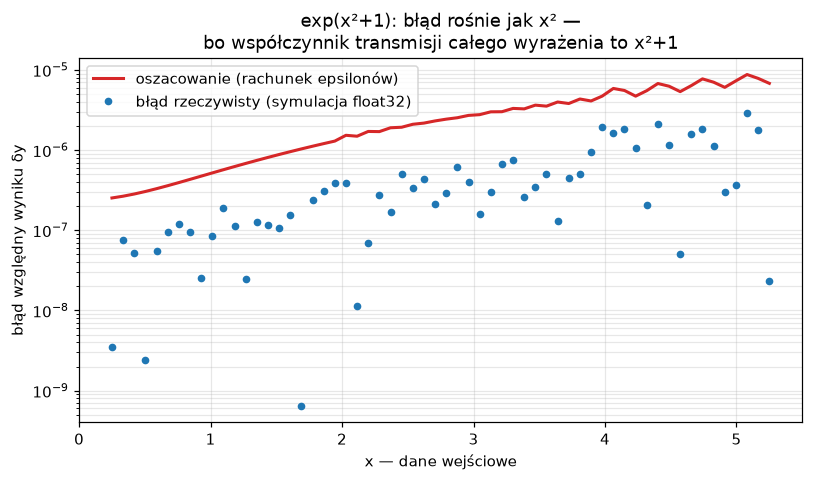

In [10]:
# Wykres: blad rzeczywisty (punkty) vs oszacowanie z rachunku epsilonow (linia).
xs_tab = np.linspace(0.25, 5.25, 60)
actuals, bounds = [], []
for xt in xs_tab:
    x32 = f32(xt)
    dx_in = abs(float(x32) - xt) / xt
    bounds.append(xt**2 * (2*dx_in + 2*eps32) + 2*eps32)
    actuals.append(abs(float(maszyna_f32(x32)) - math.exp(xt**2+1)) / math.exp(xt**2+1))

plt.figure(figsize=(7.5, 4.5))
plt.semilogy(xs_tab, bounds, 'tab:red', lw=2, label='oszacowanie (rachunek epsilonów)')
plt.semilogy(xs_tab, actuals, 'o', ms=4, color='tab:blue', label='błąd rzeczywisty (symulacja float32)')
plt.xlabel('x — dane wejściowe'); plt.ylabel('błąd względny wyniku δy')
plt.title('exp(x²+1): błąd rośnie jak x² —\nbo współczynnik transmisji całego wyrażenia to x²+1')
plt.legend(); plt.grid(alpha=.3, which='both'); plt.tight_layout(); plt.show()

## Najważniejsze wnioski

- Błąd danych przechodzi przez funkcję wzmocniony o współczynnik transmisji
  $T = |(x/y)\cdot f'(x)|$; dla wielu danych błędy wkładów się **sumują**.
- $T$ zależy od operacji (potęga $\to$ $T$ = stopień; pierwiastek $\to$ $T = 1/2$)
  **i od punktu** (exp: $T=x$; funkcje bliskie zera: $T \to \infty$).
- Wzór liniowy to przybliżenie: znakomity dla błędów promili (rura), zaniżający
  dla błędów kilku procent (kostka) — człony wyższych rzędów sumują się do punktów procentowych.
- Każda operacja elementarna maszyny **dokłada własny błąd zaokrąglenia** $\eta$
  (rachunek epsilonów); błędy zaokrągleń sumują się w kaskadzie operacji.
- Dokładność wyniku zależy nie tylko od błędu danych, ale od **poziomu samych danych**
  (przykład exp(x²+1): błąd rośnie jak x²) — dlatego algorytmy "nieczułe na poziom danych"
  są szczególnie cenne.

In [12]:
# ĆWICZENIE (szkielet — uzupełnij miejsca oznaczone TODO):
#
# 1) Policz T dla f(x) = 1/x. Czy dzielenie wzmacnia, czy tłumi błąd względny?
#    Sprawdź numerycznie: zaburz x=2 o +1% i zobacz, o ile % zmienia się y.
x = 2.0
y_dokl = None      # TODO: 1/x
y_zab  = None      # TODO: 1/(x*1.01)
# print(abs(y_zab - y_dokl)/y_dokl)   # powinno wyjść ~1% (T=1)

# 2) Powtórz symulację kostki z błędem linijki 1% zamiast 5% (gestosc nadal 8%).
#    O ile punktów procentowych najgorszy przypadek MC przekracza oszacowanie liniowe
#    (3*1% + 8% = 11%)? Porównaj z "przewidywanymi" członami krzyżowymi 3*da*drho.
#    (Oczekiwanie: przy mniejszym błędzie wzór liniowy trzyma znacznie lepiej.)

# 3) Przeanalizuj T dla y = sin(x) w punkcie x=3.1 (blisko pierwiastka pi):
#    zaburz argument o 0.1% i zmierz względny błąd wyniku. Wyjaśnij, dlaczego
#    błąd wybuchła, mimo że argument zmienił się minimalnie.


## Wykorzystywane funkcje

- `f32(u)` — rzutowanie na float32: modeluje jedną operację maszyny z zaokrągleniem,
- `maszyna_f32(x)` — kaskada operacji elementarnych exp(x²+1) krok po kroku,
- `np.nextafter` — najmniejsza reprezentowalna liczba powyżej 1 (epsilon maszynowy),
- `rng.uniform(lo, hi, N)` (`np.random.default_rng`) — generator do symulacji Monte Carlo.

## Ćwiczenie — wskazówki

1) T dla 1/x: policz pochodną i podstaw do wzoru — wynik zaskakuje (T=1, dzielenie
   przez dużą liczbę nie wzmacnia błędu względnego).
2) skopiuj komórkę Demo 3 i zmień `0.05` na `0.01`; porównaj różnicę
   „MC max − oszacowanie liniowe" z wartością 3·da·drho.
3) policz T w x=3.1 ze wzoru x·cot(x) — a potem porównaj z pomiarem.